Artificial Intelligence (AI) - The Broadest Scope:

    AI is the overarching field of computer science focused on creating systems that can perform tasks that typically require human intelligence. This includes reasoning, problem-solving, perception, and language understanding.

    Goal: Make machines "smart."

    Examples: Expert systems (1990s chess bots), rule-based chatbots, and even your smartphone's autocorrect.

Machine Learning (ML) - The Subset of AI:

    ML is the method by which we achieve AI. Instead of hard-coding explicit rules ("If X happens, do Y"), ML algorithms learn patterns directly from data. They improve their performance as they are exposed to more data over time.

    Goal: Make machines that can "learn" from data without being explicitly programmed.

    Examples: Spam filters (learning to identify spam from thousands of emails), Netflix recommendation engines, and housing price prediction models.

Deep Learning (DL) - The Subset of ML:

    DL is a specialized, modern branch of ML. It uses neural networks with many layers (hence "deep") to process data in a way that mimics the human brain's structure. Deep Learning excels at unstructured data like images, audio, and text.

    Goal: Model extremely complex patterns using artificial "neurons" stacked in layers.

    Examples: Self-driving car vision (identifying pedestrians), voice assistants (like Siri/Alexa), and Generative AI (ChatGPT, Midjourney).

Examples for ML:  - Linear regression , Logistic regression or binar classification.

## 

## LINEAR REGRESSION (Predicting Continuous Numbers)

    What it does: Predicts a continuous numeric value (like price, temperature, or salary) based on input features.

    The Math: Finds the best-fitting straight line (or hyperplane) through your data by minimizing the difference between predicted and actual values. The equation is:

    y = mx + b (for 1 feature) or y = w₁x₁ + w₂x₂ + ... + b (for multiple features)

    Loss Function: Mean Squared Error (MSE) - it measures the average squared difference between predictions and actual values.

    When to use: House price prediction, sales forecasting, temperature estimation, etc.

## LOGISTIC REGRESSION (Predicting Categories/Classes)

    What it does: Predicts the probability that something belongs to a specific category (like Yes/No, Spam/Not Spam, Pass/Fail). Despite the name, it's a classification algorithm, not regression!

    The Math: Passes the linear equation through a Sigmoid function (S-curve) that squashes the output between 0 and 1. If probability > 0.5, we predict Class 1; otherwise, Class 0.

    p = 1 / (1 + e^(-(wx + b))) → This gives a probability between 0 and 1.

    Loss Function: Log Loss (Cross-Entropy) - it penalizes confident wrong predictions heavily.

    When to use: Email spam detection, medical diagnosis (disease/no disease), customer churn prediction, etc.

Key Difference at a Glance:

    Feature	        Linear Regression	        Logistic Regression

    Output	        Continuous (e.g., 250,000)	Probability (0 to 1) → Class label (0 or 1)

    Equation	    y = wx + b	                p = 1/(1 + e^(-(wx + b))) - Sigmoid function

    Use Case	    Regression tasks	        Binary classification tasks
    
    Loss Function	Mean Squared Error	        Log Loss (Cross-Entropy)

In [15]:
# !pip install numpy

In [16]:
# !pip install pandas matplotlib seaborn scikit-learn

In [17]:
# ============================================
# COMPLETE CODE: Linear & Logistic Regression
# ============================================

# Step 1: Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler


In [18]:
# Set random seed for reproducibility
np.random.seed(42)

# ============================================
# PART 1: CREATE SYNTHETIC DATASET
# ============================================

# Generate study hours (feature) - 100 students, ranging from 0 to 10 hours
study_hours = np.random.uniform(0, 10, 100).reshape(-1, 1)


In [19]:
# --- For Linear Regression (Exam Score) ---
# True relationship: Score = 8 * hours + 30 + some random noise
true_slope = 8
true_intercept = 30
noise = np.random.normal(0, 5, 100)  # Add some random noise
exam_scores = true_slope * study_hours.flatten() + true_intercept + noise

# --- For Logistic Regression (Pass/Fail) ---
# A student passes if their exam score >= 50
pass_fail = (exam_scores >= 50).astype(int)  # 1 = Pass, 0 = Fail

# Reshape study_hours for sklearn
study_hours = study_hours.reshape(-1, 1)


In [20]:
# ============================================
# PART 2: TRAIN-TEST SPLIT (70% train, 30% test)
# ============================================

# For Linear Regression
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    study_hours, exam_scores, test_size=0.3, random_state=42
)

# For Logistic Regression
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    study_hours, pass_fail, test_size=0.3, random_state=42
)


In [21]:
# ============================================
# PART 3: LINEAR REGRESSION MODEL
# ============================================

print("="*60)
print("LINEAR REGRESSION: Predicting Exam Scores")
print("="*60)

# Create and train the model
linear_model = LinearRegression()
linear_model.fit(X_train_lr, y_train_lr)

# Make predictions
y_pred_lr = linear_model.predict(X_test_lr)

# Evaluate the model
mse = mean_squared_error(y_test_lr, y_pred_lr)
r2 = r2_score(y_test_lr, y_pred_lr)

print(f"Model Equation: Score = {linear_model.coef_[0]:.2f} * Hours + {linear_model.intercept_:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score (accuracy of the model): {r2:.4f}")
print(f"Actual slope (true): {true_slope}")
print(f"Actual intercept (true): {true_intercept}")


LINEAR REGRESSION: Predicting Exam Scores
Model Equation: Score = 7.77 * Hours + 30.59
Mean Squared Error: 15.77
R² Score (accuracy of the model): 0.9771
Actual slope (true): 8
Actual intercept (true): 30


In [22]:
# ============================================
# PART 4: LOGISTIC REGRESSION MODEL
# ============================================

print("\n" + "="*60)
print("LOGISTIC REGRESSION: Predicting Pass/Fail")
print("="*60)

# Standardize the features (important for logistic regression)
scaler = StandardScaler()
X_train_log_scaled = scaler.fit_transform(X_train_log)
X_test_log_scaled = scaler.transform(X_test_log)

# Create and train the model
logistic_model = LogisticRegression()
logistic_model.fit(X_train_log_scaled, y_train_log)

# Make predictions
y_pred_log = logistic_model.predict(X_test_log_scaled)
y_pred_prob = logistic_model.predict_proba(X_test_log_scaled)[:, 1]  # Probability of passing

# Evaluate the model
accuracy = accuracy_score(y_test_log, y_pred_log)
conf_matrix = confusion_matrix(y_test_log, y_pred_log)

print(f"Accuracy: {accuracy:.2%}")
print("Confusion Matrix:")
print(conf_matrix)
print("\nInterpretation of Confusion Matrix:")
print(f"  - True Negatives (Correctly predicted Fail): {conf_matrix[0][0]}")
print(f"  - False Positives (Predicted Pass but actually Fail): {conf_matrix[0][1]}")
print(f"  - False Negatives (Predicted Fail but actually Pass): {conf_matrix[1][0]}")
print(f"  - True Positives (Correctly predicted Pass): {conf_matrix[1][1]}")



LOGISTIC REGRESSION: Predicting Pass/Fail
Accuracy: 100.00%
Confusion Matrix:
[[11  0]
 [ 0 19]]

Interpretation of Confusion Matrix:
  - True Negatives (Correctly predicted Fail): 11
  - False Positives (Predicted Pass but actually Fail): 0
  - False Negatives (Predicted Fail but actually Pass): 0
  - True Positives (Correctly predicted Pass): 19


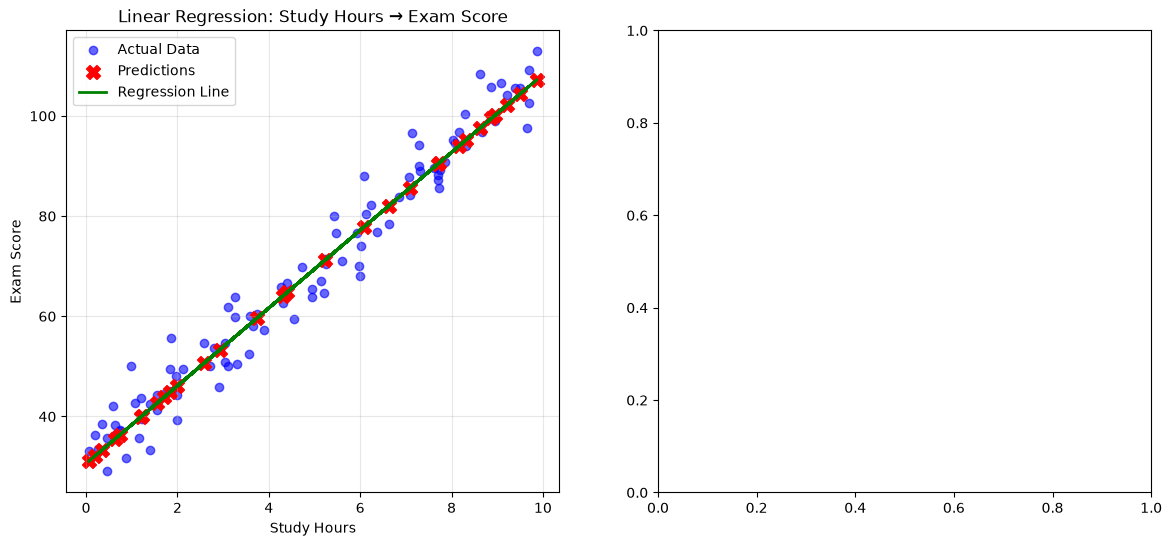

In [23]:
# ============================================
# PART 5: VISUALIZATION
# ============================================

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Linear Regression ---
ax1.scatter(study_hours, exam_scores, color='blue', alpha=0.6, label='Actual Data')
ax1.scatter(X_test_lr, y_pred_lr, color='red', marker='X', s=100, label='Predictions')
ax1.plot(study_hours, linear_model.predict(study_hours), color='green', linewidth=2, label='Regression Line')
ax1.set_xlabel('Study Hours')
ax1.set_ylabel('Exam Score')
ax1.set_title('Linear Regression: Study Hours → Exam Score')
ax1.legend()
ax1.grid(True, alpha=0.3)


In [24]:
# --- Plot 2: Logistic Regression ---
# Plot the actual data points
for i in range(len(study_hours)):
    color = 'green' if pass_fail[i] == 1 else 'red'
    marker = '^' if pass_fail[i] == 1 else 'v'
    ax2.scatter(study_hours[i], pass_fail[i], color=color, marker=marker, s=100, alpha=0.6)

# Plot the probability curve
hours_sorted = np.sort(study_hours, axis=0)
hours_scaled_sorted = scaler.transform(hours_sorted)
prob_sorted = logistic_model.predict_proba(hours_scaled_sorted)[:, 1]
ax2.plot(hours_sorted, prob_sorted, color='blue', linewidth=2, label='Sigmoid Curve (Probability of Passing)')

# Mark the decision boundary (50% probability)
ax2.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Decision Boundary (p=0.5)')
ax2.set_xlabel('Study Hours')
ax2.set_ylabel('Probability of Passing')
ax2.set_title('Logistic Regression: Study Hours → Pass/Fail')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [27]:
# ============================================
# PART 6: MAKING NEW PREDICTIONS
# ============================================

print("\n" + "="*60)
print("MAKING PREDICTIONS FOR NEW STUDENTS")
print("="*60)

# Let's test with new students
new_student_hours = np.array([[2.5], [5.0], [7.5], [9.0]])

# Linear Regression prediction (raw score)
predicted_scores = linear_model.predict(new_student_hours)

# Logistic Regression prediction (pass/fail)
new_hours_scaled = scaler.transform(new_student_hours)
predicted_classes = logistic_model.predict(new_hours_scaled)
predicted_probs = logistic_model.predict_proba(new_hours_scaled)[:, 1]

print("New Students Data:")
print("-"*50)
for i in range(len(new_student_hours)):
    hours = new_student_hours[i][0]
    score = predicted_scores[i]
    status = "PASS ✅" if predicted_classes[i] == 1 else "FAIL ❌"
    prob = predicted_probs[i]
    print(f"Student {i+1}: Hours={hours:.1f} → Predicted Score={score:.1f}, Probability of Passing={prob:.2%}, Status={status}")

print("\n" + "="*60)


MAKING PREDICTIONS FOR NEW STUDENTS
New Students Data:
--------------------------------------------------
Student 1: Hours=2.5 → Predicted Score=50.0, Probability of Passing=59.38%, Status=PASS ✅
Student 2: Hours=5.0 → Predicted Score=69.4, Probability of Passing=94.69%, Status=PASS ✅
Student 3: Hours=7.5 → Predicted Score=88.8, Probability of Passing=99.54%, Status=PASS ✅
Student 4: Hours=9.0 → Predicted Score=100.5, Probability of Passing=99.90%, Status=PASS ✅



PART 1: INTRODUCTION – WHAT IS GENERATIVE AI?

Generative AI refers to a subset of artificial intelligence that focuses on creating new content rather than just analyzing or classifying existing data. While traditional AI answers questions like "Is this a cat or a dog?" or "Will this customer churn?", Generative AI answers prompts like "Write a poem about a cat", "Create an image of a dog in a spacesuit", or "Compose a symphony in the style of Beethoven."

At its core, Generative AI learns the underlying patterns, distributions, and structures of training data and then uses that understanding to produce novel, original outputs that didn't exist before. This is fundamentally different from discriminative models, which simply draw boundaries between categories.

Key distinction:

    Discriminative AI: Learns the boundary between classes (e.g., "this email is spam because it has these patterns")

    Generative AI: Learns the entire data distribution and can sample from it to create new instances (e.g., "write a new email that looks like spam but isn't actually spam")

PART 2: EARLY FOUNDATIONS (1950s – 1980s) – THE DAWN OF CREATIVITY
The Birth of AI and Early Experiments

The seeds of Generative AI were planted alongside the birth of AI itself:

1950s: Alan Turing and the Imitation Game

    Alan Turing proposed the Turing Test as a way to measure machine intelligence. While not directly generative, it introduced the idea that machines could produce human-like responses—essentially generating text that fools humans.

    Turing also speculated about machines that could learn and evolve, laying philosophical groundwork.

1956: The Dartmouth Conference

    The official birth of AI as a field. Early researchers were wildly optimistic, believing machines would match human intelligence within a generation.

    Focus was on symbolic AI—using logic rules and symbols to represent knowledge. Generative capabilities were limited to rule-based text generation (like ELIZA, which we'll discuss shortly).

1960s: Markov Chains – The First Statistical Generators

    Andrey Markov (early 20th century) had developed Markov chains, but they gained AI relevance in the 1960s.

    Markov chains model sequences where the next state depends only on the current state. They became the first statistical method for generating text, music, and other sequences.

    Example: A Markov chain trained on Shakespeare's works could generate new text that looks Shakespearean, but it lacks long-term coherence.

1966: ELIZA – The First Chatbot

    Developed by Joseph Weizenbaum at MIT, ELIZA simulated a Rogerian psychotherapist.

    It used simple pattern matching and substitution to generate responses. For example, if the user said "I am sad," ELIZA would respond "Why do you think you are sad?"

    Although primitive, ELIZA was the first program that appeared to generate human-like conversation. Many users attributed human-like understanding to it—demonstrating the power of even simple generative systems.

1970s-1980s: Rule-Based and Template-Based Generation

    AI shifted toward expert systems that encoded human knowledge into rules.

    Content generation relied on templates—pre-written structures with slots to fill.

    Example: Weather report generators that plug temperature and conditions into fixed sentences.

    Limitations: Extremely rigid, repetitive, and couldn't handle creativity or novelty.

The State of Play (1980s): Generative systems were deterministic, brittle, and entirely human-designed. They could mimic but never innovate.
PART 3: STATISTICAL REVOLUTION (1990s – 2000s) – PROBABILISTIC GENERATION
The Shift from Rules to Data

The 1990s marked a fundamental paradigm shift: instead of programming rules, researchers began learning patterns from data.

Late 1980s – Early 1990s: Connectionism and Neural Networks Resurgence

    Neural networks, which had been largely abandoned since the 1970s, made a comeback with backpropagation (Werbos, 1974; popularized by Rumelhart et al., 1986).

    Researchers began exploring how neural networks could generate sequences.

1990s: N-Gram Models and Statistical Language Modeling

    N-gram models became the standard for text generation. They calculate the probability of a word given the previous N-1 words.

    Example: A bigram model predicts the next word based solely on the previous word. A trigram uses the previous two words.

    Limitations:

        Data sparsity (many word combinations never appear in training)

        Limited context window (can't look more than N-1 words back)

        Suffered from repetition and incoherence over longer sequences

1990s: Hidden Markov Models (HMMs)

    HMMs extended Markov chains by incorporating hidden states—unobserved variables that influence observed outputs.

    Widely used for speech recognition and early machine translation, where generating a sequence (transcription or translation) was the goal.

1997: Long Short-Term Memory (LSTM) – A Major Breakthrough

    Developed by Hochreiter & Schmidhuber, LSTMs solved the vanishing gradient problem that plagued traditional RNNs (Recurrent Neural Networks).

    LSTMs could remember information over thousands of steps, making them capable of generating coherent text paragraphs, music sequences, and more.

    For the first time, a neural network could generate contextually relevant content that maintained coherence over longer stretches.

2000s: Rise of Deep Learning and Autoencoders

    Autoencoders (Hinton & Salakhutdinov, 2006) learned compressed representations of data and could reconstruct it.

    Denoising Autoencoders could generate clean outputs from noisy inputs.

    These laid the groundwork for representation learning—the idea that if you can encode data well, you can decode to generate new data.

    However, generation was still restricted to reconstruction rather than true novel creation.

The State of Play (2000s): Generation was improving but remained limited to short sequences and simple structures. Music generation, basic text generation, and image reconstruction were possible but not yet convincing at scale.
PART 4: DEEP LEARNING REVOLUTION (2010 – 2017) – THE GAN BREAKTHROUGH
The Era of High-Quality Generation

This period witnessed explosive growth in generative capabilities, largely driven by three major innovations: GANs, VAEs, and the early Transformer.

2013: Variational Autoencoders (VAEs)

    Introduced by Kingma & Welling, VAEs blended autoencoders with probabilistic modeling.

    Instead of encoding to a single point, VAEs encode to a distribution (mean and variance). Sampling from this distribution allows for controlled generation.

    Significance: VAEs could generate smooth interpolations between data points (e.g., morphing a handwritten "2" into a "3").

    Limitation: Generated outputs tended to be blurry due to the averaging nature of the loss function.

2014: Generative Adversarial Networks (GANs) – The Game Changer

    Introduced by Ian Goodfellow (then a PhD student at Université de Montréal) in a late-night brainstorming session.

    GANs consist of two neural networks:

        Generator: Creates fake data (e.g., images)

        Discriminator: Tries to distinguish real data from fake data

    The two networks compete in a zero-sum game: the Generator tries to fool the Discriminator, while the Discriminator tries to get better at detecting fakes.

    Significance: GANs produced photorealistic images for the first time. They could generate faces, landscapes, and artwork that were indistinguishable from real photos.

    Breakthrough: Generated images were sharp, not blurry (unlike VAEs).

The GAN Family Explodes (2015–2017)

    DCGAN (Radford et al., 2015): Convolutional GANs that stabilized training and produced higher-quality images.

    StyleGAN (Karras et al., 2018): Allowed control over different aspects of generated images (hair color, face shape, style).

    CycleGAN (Zhu et al., 2017): Could translate images from one domain to another without paired training data (e.g., turning horses into zebras).

    GANs expanded beyond images: Music GANs, Text GANs (though text remained challenging due to discrete outputs).

2014: Sequence-to-Sequence Models (Seq2Seq)

    Introduced by Sutskever et al. for machine translation.

    Used encoder-decoder architecture with LSTMs or GRUs.

    Enabled variable-length generation: take a sequence of any length and output a sequence of any length.

    Foundation for chatbots, summarization, and machine translation (Google Translate improved dramatically).

2015: Attention Mechanism

    Proposed by Bahdanau et al., attention allowed the decoder to "look back" at all encoder outputs when generating each word.

    Solved the bottleneck problem where all information had to pass through a fixed-length vector.

    Attention became the foundation for the Transformer architecture.

2017: The Transformer – The Architecture That Changed Everything

    Introduced in the paper "Attention Is All You Need" by Vaswani et al. (Google Brain).

    Eliminated recurrence entirely, relying solely on self-attention mechanisms.

    Key innovations:

        Multi-head attention: Captures different types of relationships simultaneously.

        Positional encoding: Adds sequence order information since transformers aren't inherently sequential.

        Parallelization: Transformers could train on massive datasets using GPUs/TPUs efficiently.

    The Transformer was the catalyst that made large-scale generative models possible.

The State of Play (2017): We had GANs generating incredible images, VAEs for interpolation, and the Transformer was poised to revolutionize language. But the era of scaling was just beginning.
PART 5: THE SCALING ERA (2018 – 2022) – BIGGER IS BETTER
Big Models, Big Data, Big Compute

Researchers discovered that scaling up transformers—more parameters, more data, more compute—led to emergent capabilities not present in smaller models.

2018: BERT (Bidirectional Encoder Representations from Transformers)

    Introduced by Google.

    BERT was primarily a discriminative model (excellent at understanding language), but it pioneered the pre-training + fine-tuning paradigm that would be critical for generative models.

    Showed that massive pre-training on unlabeled text (BooksCorpus + Wikipedia) yielded incredible language understanding.

2018: GPT-1 (Generative Pre-trained Transformer)

    OpenAI released the first GPT model with 117 million parameters.

    Showed that a transformer decoder trained on a large corpus (BookCorpus) could generate coherent text and achieve strong performance on downstream tasks without fine-tuning.

2019: GPT-2 – The "Too Dangerous to Release" Model

    1.5 billion parameters, trained on 40GB of internet text (WebText dataset).

    Generated remarkably coherent, human-like text across various topics.

    OpenAI initially withheld the full model, citing concerns about malicious use (fake news, spam, impersonation).

    Generated massive public debate about AI safety and ethics.

    Later released in stages, showing that the genie was out of the bottle.

2020: GPT-3 – The Game-Changer

    175 billion parameters (100x GPT-2).

    Trained on 570GB of text (including CommonCrawl, Wikipedia, books).

    Emergent abilities:

        In-context learning: Could perform tasks it wasn't explicitly trained for, just by reading a prompt with a few examples (few-shot learning).

        Zero-shot learning: Could perform tasks with just instructions, no examples.

        Generated poetry, code, stories, marketing copy, and more.

    The API launch made GPT-3 accessible to developers, sparking an explosion of applications.

2021: DALL-E 1 (OpenAI)

    Combined transformers with VQ-VAE to generate images from text descriptions.

    Could create surreal, imaginative images (e.g., "an armchair in the shape of an avocado").

    Showed that the Transformer architecture could work across modalities (text → image).

2021: CLIP (OpenAI) and Contrastive Learning

    CLIP (Contrastive Language-Image Pre-training) learned to associate images with text descriptions using contrastive loss.

    Not generative itself, but critical for evaluating and steering generative models (used in DALL-E 2 and Stable Diffusion).

2022: DALL-E 2

    Used a diffusion model (instead of GANs) combined with CLIP.

    Produced incredibly detailed, photorealistic images with better coherence and higher resolution.

    Could edit images (inpainting, outpainting) and generate variations.

    Diffusion models became the state-of-the-art for image generation, surpassing GANs in quality and diversity.

2022: Stable Diffusion (Stability AI)

    Open-sourced diffusion model.

    Could run on consumer GPUs (much less compute-intensive than DALL-E 2).

    Democratized image generation—anyone could generate images for free.

    Sparked controversy: artists' rights, copyright issues, and debates about AI art.

2022: ChatGPT (November 30, 2022) – The Tipping Point

    Built on GPT-3.5 with Reinforcement Learning from Human Feedback (RLHF) .

    RLHF aligned the model with human preferences (helpfulness, harmlessness, honesty).

    Explosive adoption: Reached 1 million users in 5 days, 100 million in 2 months.

    Marked the mainstream breakthrough of Generative AI into the public consciousness.

    ChatGPT demonstrated that Generative AI could be conversational, helpful, and interactive in ways that surprised even its creators.

The State of Play (2022): Generative AI had become a household term. Models could generate text, images, code, and even video. The floodgates were open.
PART 6: THE MULTIMODAL EXPLOSION (2023 – PRESENT) – ALL-IN-ONE MODELS
Generating Anything, Anywhere, Anytime

The current era is characterized by multimodality (handling text, images, audio, video, and more) and increasing model sizes.

2023: GPT-4 (OpenAI)

    Multimodal: Accepts text and image inputs (though image outputs came later).

    1.76 trillion parameters (estimated), significantly larger than GPT-3.

    Achieved human-level performance on many benchmarks (bar exam, SAT, etc.).

    Hallucination rates decreased but not eliminated.

    GPT-4 Turbo and GPT-4o improved speed and cost.

2023: Google's Gemini (December 2023)

    Native multimodal: Trained from the ground up on text, images, audio, video, and code.

    Could reason across modalities simultaneously.

    Ultra, Pro, and Nano versions scaled for different use cases.

    Demonstrated interactive video and audio understanding.

2023: Midjourney V5 and V6

    Continued improvements in image quality, coherence, and style control.

    Photorealism that was indistinguishable from real photography.

    Artists integrated AI into their workflows.

2023: Runway Gen-2 (Video Generation)

    Text-to-video generation of reasonable quality.

    Extended the generative frontier from images to motion.

2023: ElevenLabs – Voice Generation

    Achieved near-perfect voice cloning.

    Generated emotional, nuanced speech that was indistinguishable from human voices.

    Sparked fears of voice scams and deepfakes.

2024: Sora (OpenAI, February 2024)

    Text-to-video generation with astonishing realism and temporal coherence.

    Could generate 60-second videos with complex scenes, motion, and interactions.

    Demonstrated understanding of physics (objects falling, water splashing) at a basic level.

    Showed that scaling the diffusion/transformer hybrid to video was possible.

    Yet to be released publicly due to safety concerns.

2024: Claude 3 (Anthropic)

    3 models: Haiku, Sonnet, Opus (fastest to most capable).

    Opus demonstrated near-human comprehension on complex reasoning tasks.

    Introduced "Constitutional AI" —self-alignment with fewer human annotations.

    Strong performance on coding, reasoning, and long-context tasks (200k tokens).

2024: Llama 3 (Meta)

    Open-source model that rivaled GPT-4 in performance.

    70B and 405B parameter versions.

    Massive community adoption and fine-tuning (Llama 3.1, etc.).

    Meta positioned itself as the leader in open-source generative AI.

2024: AI Agents Emerge

    Shift from chatbots (single-turn responses) to agents (multi-step reasoning, tool use, planning).

    AutoGPT, BabyAGI, and others demonstrated that models could autonomously break down goals into subtasks.

    Integration with calendars, browsers, APIs, and other tools.

    Promises of digital employees and software that builds software.

2025-2026: Current Landscape (As of July 2026)

The field has evolved rapidly, and here's where we stand today:

Model Architectures:

    Mixture of Experts (MoE): Models like Gemini and GPT-4 use MoE to activate only relevant parts of the network, reducing inference cost.

    State-Space Models (Mamba, etc.): Alternative architectures that offer linear-time scaling, potentially replacing Transformers for long contexts.

    Diffusion-Transformer Hybrids: Combining diffusion (for iterative refinement) with transformers (for global context) for better quality and efficiency.

Multimodal Capabilities:

    Native multimodality is now standard—models can seamlessly understand and generate across text, image, audio, video, and 3D.

    Voice integration: Real-time voice conversations with natural pauses, emotions, and even singing.

    Real-time video generation: Models can generate videos in seconds, with increasing resolution and length.

Model Scale and Efficiency:

    Parameter counts have plateaued (around 1-2 trillion) as researchers focus on efficiency—smaller, smarter models.

    Quantization and pruning enable models to run on edge devices (phones, laptops).

    LoRA (Low-Rank Adaptation) and PEFT (Parameter-Efficient Fine-Tuning) make customization easy.

Key Players (2026):

    OpenAI: GPT-5 (or equivalent) with improved reasoning and reduced hallucinations.

    Google DeepMind: Gemini Ultra 2.0 with integrated search and real-time data.

    Anthropic: Claude 4 with advanced self-alignment and reasoning.

    Meta: Llama 4 (open-source) with 1 trillion+ parameters, rivaling closed models.

    X (formerly Twitter): Grok integrated with real-time social media data.

    Mistral AI: Fast, efficient models challenging the incumbents.

Application Landscape:

    Enterprise AI: Generative AI embedded in every software product (CRM, HR, finance, legal).

    Creative Industries: Movies, games, music, and design are increasingly AI-assisted.

    Healthcare: Drug discovery, personalized medicine, and medical imaging.

    Education: Personalized tutors, content creation, and assessment.

    Robotics: Physical world reasoning and generation of actions.

Societal and Ethical Landscape:

    Regulation: The EU AI Act and other frameworks are shaping development.

    Copyright and IP: Ongoing legal battles about training data and generated content.

    Misinformation: Deepfakes and synthetic media are a major concern.

    Job Displacement: Debates on how to reskill the workforce.

    AI Safety: Research on alignment, interpretability, and control continues.

    Open vs. Closed: Tension between open-source models (democratizing AI) and closed models (safety and monetization).

PART 7: THE FUTURE – TOMORROW'S GENERATIVE AI
Where Are We Headed?

While we can't predict the future with certainty, several trends are visible:

1. Artificial General Intelligence (AGI)

    Generative AI is seen as a stepping stone toward AGI—machines that match or exceed human intelligence across all domains.

    Some argue we're already seeing sparks of AGI in models like GPT-4 and Gemini.

2. World Models

    Models that understand and can simulate the physical world (physics, causality, agents).

    Essential for robotics, autonomous vehicles, and scientific discovery.

3. Continuous Learning

    Models that learn continuously from interaction, rather than being frozen after training.

    Reduces hallucinations and keeps knowledge current.

4. Long-Term Memory

    Models with persistent memory across sessions, remembering past interactions and preferences.

    Personalized AI companions.

5. Multi-Agent Systems

    Swarms of AI agents collaborating to solve complex problems (e.g., running a company, conducting research).

6. Generative Physics

    Simulating entire universes, weather systems, or molecular interactions with generative models.

7. AI-Generated Content as Economic Asset

    Synthetic data, virtual influencers, AI-generated art, and code becoming major economic outputs.

8. Democratization

    Generative AI becoming as ubiquitous as the internet—embedded in every device and application.

9. Human-AI Collaboration

    Moving from "AI replaces human" to "AI amplifies human"—augmented intelligence.

10. Self-Improving AI

    Models that generate new training data, perform self-play, and improve themselves without human intervention.

In [26]:
PART 1: INTRODUCTION – WHAT IS GENERATIVE AI?

Generative AI refers to a subset of artificial intelligence that focuses on creating new content rather than just analyzing or classifying existing data. While traditional AI answers questions like "Is this a cat or a dog?" or "Will this customer churn?", Generative AI answers prompts like "Write a poem about a cat", "Create an image of a dog in a spacesuit", or "Compose a symphony in the style of Beethoven."

At its core, Generative AI learns the underlying patterns, distributions, and structures of training data and then uses that understanding to produce novel, original outputs that didn't exist before. This is fundamentally different from discriminative models, which simply draw boundaries between categories.

Key distinction:

    Discriminative AI: Learns the boundary between classes (e.g., "this email is spam because it has these patterns")

    Generative AI: Learns the entire data distribution and can sample from it to create new instances (e.g., "write a new email that looks like spam but isn't actually spam")

PART 2: EARLY FOUNDATIONS (1950s – 1980s) – THE DAWN OF CREATIVITY
The Birth of AI and Early Experiments

The seeds of Generative AI were planted alongside the birth of AI itself:

1950s: Alan Turing and the Imitation Game

    Alan Turing proposed the Turing Test as a way to measure machine intelligence. While not directly generative, it introduced the idea that machines could produce human-like responses—essentially generating text that fools humans.

    Turing also speculated about machines that could learn and evolve, laying philosophical groundwork.

1956: The Dartmouth Conference

    The official birth of AI as a field. Early researchers were wildly optimistic, believing machines would match human intelligence within a generation.

    Focus was on symbolic AI—using logic rules and symbols to represent knowledge. Generative capabilities were limited to rule-based text generation (like ELIZA, which we'll discuss shortly).

1960s: Markov Chains – The First Statistical Generators

    Andrey Markov (early 20th century) had developed Markov chains, but they gained AI relevance in the 1960s.

    Markov chains model sequences where the next state depends only on the current state. They became the first statistical method for generating text, music, and other sequences.

    Example: A Markov chain trained on Shakespeare's works could generate new text that looks Shakespearean, but it lacks long-term coherence.

1966: ELIZA – The First Chatbot

    Developed by Joseph Weizenbaum at MIT, ELIZA simulated a Rogerian psychotherapist.

    It used simple pattern matching and substitution to generate responses. For example, if the user said "I am sad," ELIZA would respond "Why do you think you are sad?"

    Although primitive, ELIZA was the first program that appeared to generate human-like conversation. Many users attributed human-like understanding to it—demonstrating the power of even simple generative systems.

1970s-1980s: Rule-Based and Template-Based Generation

    AI shifted toward expert systems that encoded human knowledge into rules.

    Content generation relied on templates—pre-written structures with slots to fill.

    Example: Weather report generators that plug temperature and conditions into fixed sentences.

    Limitations: Extremely rigid, repetitive, and couldn't handle creativity or novelty.

The State of Play (1980s): Generative systems were deterministic, brittle, and entirely human-designed. They could mimic but never innovate.
PART 3: STATISTICAL REVOLUTION (1990s – 2000s) – PROBABILISTIC GENERATION
The Shift from Rules to Data

The 1990s marked a fundamental paradigm shift: instead of programming rules, researchers began learning patterns from data.

Late 1980s – Early 1990s: Connectionism and Neural Networks Resurgence

    Neural networks, which had been largely abandoned since the 1970s, made a comeback with backpropagation (Werbos, 1974; popularized by Rumelhart et al., 1986).

    Researchers began exploring how neural networks could generate sequences.

1990s: N-Gram Models and Statistical Language Modeling

    N-gram models became the standard for text generation. They calculate the probability of a word given the previous N-1 words.

    Example: A bigram model predicts the next word based solely on the previous word. A trigram uses the previous two words.

    Limitations:

        Data sparsity (many word combinations never appear in training)

        Limited context window (can't look more than N-1 words back)

        Suffered from repetition and incoherence over longer sequences

1990s: Hidden Markov Models (HMMs)

    HMMs extended Markov chains by incorporating hidden states—unobserved variables that influence observed outputs.

    Widely used for speech recognition and early machine translation, where generating a sequence (transcription or translation) was the goal.

1997: Long Short-Term Memory (LSTM) – A Major Breakthrough

    Developed by Hochreiter & Schmidhuber, LSTMs solved the vanishing gradient problem that plagued traditional RNNs (Recurrent Neural Networks).

    LSTMs could remember information over thousands of steps, making them capable of generating coherent text paragraphs, music sequences, and more.

    For the first time, a neural network could generate contextually relevant content that maintained coherence over longer stretches.

2000s: Rise of Deep Learning and Autoencoders

    Autoencoders (Hinton & Salakhutdinov, 2006) learned compressed representations of data and could reconstruct it.

    Denoising Autoencoders could generate clean outputs from noisy inputs.

    These laid the groundwork for representation learning—the idea that if you can encode data well, you can decode to generate new data.

    However, generation was still restricted to reconstruction rather than true novel creation.

The State of Play (2000s): Generation was improving but remained limited to short sequences and simple structures. Music generation, basic text generation, and image reconstruction were possible but not yet convincing at scale.
PART 4: DEEP LEARNING REVOLUTION (2010 – 2017) – THE GAN BREAKTHROUGH
The Era of High-Quality Generation

This period witnessed explosive growth in generative capabilities, largely driven by three major innovations: GANs, VAEs, and the early Transformer.

2013: Variational Autoencoders (VAEs)

    Introduced by Kingma & Welling, VAEs blended autoencoders with probabilistic modeling.

    Instead of encoding to a single point, VAEs encode to a distribution (mean and variance). Sampling from this distribution allows for controlled generation.

    Significance: VAEs could generate smooth interpolations between data points (e.g., morphing a handwritten "2" into a "3").

    Limitation: Generated outputs tended to be blurry due to the averaging nature of the loss function.

2014: Generative Adversarial Networks (GANs) – The Game Changer

    Introduced by Ian Goodfellow (then a PhD student at Université de Montréal) in a late-night brainstorming session.

    GANs consist of two neural networks:

        Generator: Creates fake data (e.g., images)

        Discriminator: Tries to distinguish real data from fake data

    The two networks compete in a zero-sum game: the Generator tries to fool the Discriminator, while the Discriminator tries to get better at detecting fakes.

    Significance: GANs produced photorealistic images for the first time. They could generate faces, landscapes, and artwork that were indistinguishable from real photos.

    Breakthrough: Generated images were sharp, not blurry (unlike VAEs).

The GAN Family Explodes (2015–2017)

    DCGAN (Radford et al., 2015): Convolutional GANs that stabilized training and produced higher-quality images.

    StyleGAN (Karras et al., 2018): Allowed control over different aspects of generated images (hair color, face shape, style).

    CycleGAN (Zhu et al., 2017): Could translate images from one domain to another without paired training data (e.g., turning horses into zebras).

    GANs expanded beyond images: Music GANs, Text GANs (though text remained challenging due to discrete outputs).

2014: Sequence-to-Sequence Models (Seq2Seq)

    Introduced by Sutskever et al. for machine translation.

    Used encoder-decoder architecture with LSTMs or GRUs.

    Enabled variable-length generation: take a sequence of any length and output a sequence of any length.

    Foundation for chatbots, summarization, and machine translation (Google Translate improved dramatically).

2015: Attention Mechanism

    Proposed by Bahdanau et al., attention allowed the decoder to "look back" at all encoder outputs when generating each word.

    Solved the bottleneck problem where all information had to pass through a fixed-length vector.

    Attention became the foundation for the Transformer architecture.

2017: The Transformer – The Architecture That Changed Everything

    Introduced in the paper "Attention Is All You Need" by Vaswani et al. (Google Brain).

    Eliminated recurrence entirely, relying solely on self-attention mechanisms.

    Key innovations:

        Multi-head attention: Captures different types of relationships simultaneously.

        Positional encoding: Adds sequence order information since transformers aren't inherently sequential.

        Parallelization: Transformers could train on massive datasets using GPUs/TPUs efficiently.

    The Transformer was the catalyst that made large-scale generative models possible.

The State of Play (2017): We had GANs generating incredible images, VAEs for interpolation, and the Transformer was poised to revolutionize language. But the era of scaling was just beginning.
PART 5: THE SCALING ERA (2018 – 2022) – BIGGER IS BETTER
Big Models, Big Data, Big Compute

Researchers discovered that scaling up transformers—more parameters, more data, more compute—led to emergent capabilities not present in smaller models.

2018: BERT (Bidirectional Encoder Representations from Transformers)

    Introduced by Google.

    BERT was primarily a discriminative model (excellent at understanding language), but it pioneered the pre-training + fine-tuning paradigm that would be critical for generative models.

    Showed that massive pre-training on unlabeled text (BooksCorpus + Wikipedia) yielded incredible language understanding.

2018: GPT-1 (Generative Pre-trained Transformer)

    OpenAI released the first GPT model with 117 million parameters.

    Showed that a transformer decoder trained on a large corpus (BookCorpus) could generate coherent text and achieve strong performance on downstream tasks without fine-tuning.

2019: GPT-2 – The "Too Dangerous to Release" Model

    1.5 billion parameters, trained on 40GB of internet text (WebText dataset).

    Generated remarkably coherent, human-like text across various topics.

    OpenAI initially withheld the full model, citing concerns about malicious use (fake news, spam, impersonation).

    Generated massive public debate about AI safety and ethics.

    Later released in stages, showing that the genie was out of the bottle.

2020: GPT-3 – The Game-Changer

    175 billion parameters (100x GPT-2).

    Trained on 570GB of text (including CommonCrawl, Wikipedia, books).

    Emergent abilities:

        In-context learning: Could perform tasks it wasn't explicitly trained for, just by reading a prompt with a few examples (few-shot learning).

        Zero-shot learning: Could perform tasks with just instructions, no examples.

        Generated poetry, code, stories, marketing copy, and more.

    The API launch made GPT-3 accessible to developers, sparking an explosion of applications.

2021: DALL-E 1 (OpenAI)

    Combined transformers with VQ-VAE to generate images from text descriptions.

    Could create surreal, imaginative images (e.g., "an armchair in the shape of an avocado").

    Showed that the Transformer architecture could work across modalities (text → image).

2021: CLIP (OpenAI) and Contrastive Learning

    CLIP (Contrastive Language-Image Pre-training) learned to associate images with text descriptions using contrastive loss.

    Not generative itself, but critical for evaluating and steering generative models (used in DALL-E 2 and Stable Diffusion).

2022: DALL-E 2

    Used a diffusion model (instead of GANs) combined with CLIP.

    Produced incredibly detailed, photorealistic images with better coherence and higher resolution.

    Could edit images (inpainting, outpainting) and generate variations.

    Diffusion models became the state-of-the-art for image generation, surpassing GANs in quality and diversity.

2022: Stable Diffusion (Stability AI)

    Open-sourced diffusion model.

    Could run on consumer GPUs (much less compute-intensive than DALL-E 2).

    Democratized image generation—anyone could generate images for free.

    Sparked controversy: artists' rights, copyright issues, and debates about AI art.

2022: ChatGPT (November 30, 2022) – The Tipping Point

    Built on GPT-3.5 with Reinforcement Learning from Human Feedback (RLHF) .

    RLHF aligned the model with human preferences (helpfulness, harmlessness, honesty).

    Explosive adoption: Reached 1 million users in 5 days, 100 million in 2 months.

    Marked the mainstream breakthrough of Generative AI into the public consciousness.

    ChatGPT demonstrated that Generative AI could be conversational, helpful, and interactive in ways that surprised even its creators.

The State of Play (2022): Generative AI had become a household term. Models could generate text, images, code, and even video. The floodgates were open.
PART 6: THE MULTIMODAL EXPLOSION (2023 – PRESENT) – ALL-IN-ONE MODELS
Generating Anything, Anywhere, Anytime

The current era is characterized by multimodality (handling text, images, audio, video, and more) and increasing model sizes.

2023: GPT-4 (OpenAI)

    Multimodal: Accepts text and image inputs (though image outputs came later).

    1.76 trillion parameters (estimated), significantly larger than GPT-3.

    Achieved human-level performance on many benchmarks (bar exam, SAT, etc.).

    Hallucination rates decreased but not eliminated.

    GPT-4 Turbo and GPT-4o improved speed and cost.

2023: Google's Gemini (December 2023)

    Native multimodal: Trained from the ground up on text, images, audio, video, and code.

    Could reason across modalities simultaneously.

    Ultra, Pro, and Nano versions scaled for different use cases.

    Demonstrated interactive video and audio understanding.

2023: Midjourney V5 and V6

    Continued improvements in image quality, coherence, and style control.

    Photorealism that was indistinguishable from real photography.

    Artists integrated AI into their workflows.

2023: Runway Gen-2 (Video Generation)

    Text-to-video generation of reasonable quality.

    Extended the generative frontier from images to motion.

2023: ElevenLabs – Voice Generation

    Achieved near-perfect voice cloning.

    Generated emotional, nuanced speech that was indistinguishable from human voices.

    Sparked fears of voice scams and deepfakes.

2024: Sora (OpenAI, February 2024)

    Text-to-video generation with astonishing realism and temporal coherence.

    Could generate 60-second videos with complex scenes, motion, and interactions.

    Demonstrated understanding of physics (objects falling, water splashing) at a basic level.

    Showed that scaling the diffusion/transformer hybrid to video was possible.

    Yet to be released publicly due to safety concerns.

2024: Claude 3 (Anthropic)

    3 models: Haiku, Sonnet, Opus (fastest to most capable).

    Opus demonstrated near-human comprehension on complex reasoning tasks.

    Introduced "Constitutional AI" —self-alignment with fewer human annotations.

    Strong performance on coding, reasoning, and long-context tasks (200k tokens).

2024: Llama 3 (Meta)

    Open-source model that rivaled GPT-4 in performance.

    70B and 405B parameter versions.

    Massive community adoption and fine-tuning (Llama 3.1, etc.).

    Meta positioned itself as the leader in open-source generative AI.

2024: AI Agents Emerge

    Shift from chatbots (single-turn responses) to agents (multi-step reasoning, tool use, planning).

    AutoGPT, BabyAGI, and others demonstrated that models could autonomously break down goals into subtasks.

    Integration with calendars, browsers, APIs, and other tools.

    Promises of digital employees and software that builds software.

2025-2026: Current Landscape (As of July 2026)

The field has evolved rapidly, and here's where we stand today:

Model Architectures:

    Mixture of Experts (MoE): Models like Gemini and GPT-4 use MoE to activate only relevant parts of the network, reducing inference cost.

    State-Space Models (Mamba, etc.): Alternative architectures that offer linear-time scaling, potentially replacing Transformers for long contexts.

    Diffusion-Transformer Hybrids: Combining diffusion (for iterative refinement) with transformers (for global context) for better quality and efficiency.

Multimodal Capabilities:

    Native multimodality is now standard—models can seamlessly understand and generate across text, image, audio, video, and 3D.

    Voice integration: Real-time voice conversations with natural pauses, emotions, and even singing.

    Real-time video generation: Models can generate videos in seconds, with increasing resolution and length.

Model Scale and Efficiency:

    Parameter counts have plateaued (around 1-2 trillion) as researchers focus on efficiency—smaller, smarter models.

    Quantization and pruning enable models to run on edge devices (phones, laptops).

    LoRA (Low-Rank Adaptation) and PEFT (Parameter-Efficient Fine-Tuning) make customization easy.

Key Players (2026):

    OpenAI: GPT-5 (or equivalent) with improved reasoning and reduced hallucinations.

    Google DeepMind: Gemini Ultra 2.0 with integrated search and real-time data.

    Anthropic: Claude 4 with advanced self-alignment and reasoning.

    Meta: Llama 4 (open-source) with 1 trillion+ parameters, rivaling closed models.

    X (formerly Twitter): Grok integrated with real-time social media data.

    Mistral AI: Fast, efficient models challenging the incumbents.

Application Landscape:

    Enterprise AI: Generative AI embedded in every software product (CRM, HR, finance, legal).

    Creative Industries: Movies, games, music, and design are increasingly AI-assisted.

    Healthcare: Drug discovery, personalized medicine, and medical imaging.

    Education: Personalized tutors, content creation, and assessment.

    Robotics: Physical world reasoning and generation of actions.

Societal and Ethical Landscape:

    Regulation: The EU AI Act and other frameworks are shaping development.

    Copyright and IP: Ongoing legal battles about training data and generated content.

    Misinformation: Deepfakes and synthetic media are a major concern.

    Job Displacement: Debates on how to reskill the workforce.

    AI Safety: Research on alignment, interpretability, and control continues.

    Open vs. Closed: Tension between open-source models (democratizing AI) and closed models (safety and monetization).

PART 7: THE FUTURE – TOMORROW'S GENERATIVE AI
Where Are We Headed?

While we can't predict the future with certainty, several trends are visible:

1. Artificial General Intelligence (AGI)

    Generative AI is seen as a stepping stone toward AGI—machines that match or exceed human intelligence across all domains.

    Some argue we're already seeing sparks of AGI in models like GPT-4 and Gemini.

2. World Models

    Models that understand and can simulate the physical world (physics, causality, agents).

    Essential for robotics, autonomous vehicles, and scientific discovery.

3. Continuous Learning

    Models that learn continuously from interaction, rather than being frozen after training.

    Reduces hallucinations and keeps knowledge current.

4. Long-Term Memory

    Models with persistent memory across sessions, remembering past interactions and preferences.

    Personalized AI companions.

5. Multi-Agent Systems

    Swarms of AI agents collaborating to solve complex problems (e.g., running a company, conducting research).

6. Generative Physics

    Simulating entire universes, weather systems, or molecular interactions with generative models.

7. AI-Generated Content as Economic Asset

    Synthetic data, virtual influencers, AI-generated art, and code becoming major economic outputs.

8. Democratization

    Generative AI becoming as ubiquitous as the internet—embedded in every device and application.

9. Human-AI Collaboration

    Moving from "AI replaces human" to "AI amplifies human"—augmented intelligence.

10. Self-Improving AI

    Models that generate new training data, perform self-play, and improve themselves without human intervention.

SyntaxError: unterminated string literal (detected at line 5) (2271788616.py, line 5)

SUMMARY TIMELINE

    Era	                Period	        Key Breakthroughs

    Foundations	        1950s–1980s	    Turing Test, ELIZA, Markov Chains, rule-based systems

    Statistical ML	    1990s–2000s	    N-grams, HMMs, LSTMs, early neural networks

    Deep Learning	    2010–2017	    VAEs, GANs, Seq2Seq, Attention, Transformer

    Scaling Era	        2018–2022	    GPT-1/2/3, BERT, DALL-E 1/2, Stable Diffusion, ChatGPT

    Multimodal Era	    2023–2026	    GPT-4, Gemini, Sora, Llama 3/4, voice/video generation

    Future	            2027+	        AGI, world models, continuous learning, multi-agent systems

## AI Ethics & Responsible AI  

1. THE TROLLEY PROBLEM IN AUTONOMOUS VEHICLES

Scenario: An autonomous vehicle must choose between two terrible outcomes:

    Option A: Swerve into a group of pedestrians, killing 5 people but saving the passenger.

    Option B: Continue straight, hitting a barrier and killing the passenger but saving the 5 pedestrians.

Ethical Questions:

    Whose life should the AI prioritize?

    Should the car protect its passenger (like a human driver instinctively would) or minimize total harm (utilitarian)?

    How do we program these moral decisions?

    Who gets to decide the answer? (Manufacturers? Regulators? The public?)

    Should the car's decisions be transparent and publicly debated?

The Reality: No autonomous vehicle currently makes such explicit moral decisions—they are designed to avoid collisions entirely. But as edge cases arise, these questions become unavoidable.
2. DEEPFAKES, SYNTHETIC MEDIA, AND MISINFORMATION

Scenario: A deepfake video of a political leader saying something inflammatory goes viral before an election, causing social unrest. Or a hyper-realistic AI-generated video of a celebrity in a compromising situation is released without consent.

Ethical Questions:

    How do we detect and label synthetic media?

    What are the limits of free speech when AI can generate perfect fakes?

    How do we hold creators accountable for malicious deepfakes?

    What are the psychological harms of being unable to trust any video or audio?

Mitigation:

    Watermarking and Provenance: Embedding cryptographic signatures to verify authenticity.

    Detection Tools: AI models trained to detect deepfakes (an arms race).

    Education: Public awareness campaigns about the existence and risks of synthetic media.

    Regulation: Laws criminalizing malicious deepfakes (especially non-consensual explicit content).

3. SURVEILLANCE AND SOCIAL CONTROL

Scenario: Governments deploy AI-powered facial recognition for mass surveillance in public spaces. The system can identify citizens, track their movements, and predict "suspicious" behavior.

Ethical Questions:

    Where is the line between public safety and authoritarian control?

    What about false positives (misidentification of innocent people)?

    Can surveillance be used to suppress dissent or target minority groups?

    Should citizens have the right to opt out of being tracked?

    What are the chilling effects on free speech and freedom of assembly?

Real-World Examples:

    China's social credit system uses AI to monitor and score citizen behavior.

    Several US cities have banned facial recognition due to bias and privacy concerns.

Mitigation:

    Strict Oversight: Independent review boards and judicial approval for surveillance.

    Accuracy Standards: Minimum accuracy requirements to prevent false positives.

    Purpose Limitation: Restricting surveillance to specific, legitimate purposes (e.g., criminal investigation, not general monitoring).

    Proportionality: Surveillance should be proportional to the threat it addresses.

4. ALGORITHMIC BIAS AND SYSTEMIC DISCRIMINATION

Scenario: A predictive policing algorithm directs police resources to predominantly minority neighborhoods because historical arrest data (which reflects biased policing) shows higher arrest rates there. The increased police presence leads to more arrests, reinforcing the cycle.

Ethical Questions:

    Can AI be truly fair if the world it learns from is already unfair?

    Should we use biased data at all, knowing it will perpetuate injustice?

    How do we decide which fairness metric to use?

    Who is responsible when an algorithm causes systemic discrimination?

The "Fairness-Accuracy Trade-off": Often, making a model fairer (e.g., across racial groups) reduces its overall accuracy. Is it ethical to sacrifice accuracy for fairness—especially when lives are at stake?

Real-World Example: COMPAS (Correctional Offender Management Profiling for Alternative Sanctions)—a risk assessment tool used in US courts—was found to be biased against Black defendants. It was more likely to falsely label Black defendants as "high risk" and white defendants as "low risk."
5. JOB DISPLACEMENT AND ECONOMIC INEQUALITY

Scenario: AI automates jobs across sectors—customer service, driving, manufacturing, legal research, journalism, software development, even creative arts. Millions of workers face unemployment without alternative income sources.

Ethical Questions:

    What is the responsibility of AI developers and companies to displaced workers?

    Should we slow down AI adoption to protect jobs?

    What social safety nets are needed (e.g., Universal Basic Income, retraining programs)?

    How do we prevent AI from widening the gap between the rich (who own AI) and the poor (who are displaced by it)?

Real-World Example: The 2023 Hollywood writers' and actors' strikes had AI as a central issue—with creators demanding protections against their work being used to train AI or replace them entirely.
6. AI IN WARFARE – AUTONOMOUS WEAPONS SYSTEMS

Scenario: Lethal Autonomous Weapons (LAWS)—"killer robots"—that can select and engage targets without human intervention.

Ethical Questions:

    Is it ethical for machines to make life-and-death decisions?

    If a drone kills a civilian, who is responsible?

    How do we ensure compliance with international humanitarian law (distinction, proportionality)?

    What happens when both sides use autonomous weapons—an AI arms race with no human oversight?

The Campaign to Stop Killer Robots: An international coalition of NGOs, academics, and governments advocating for a preemptive ban on LAWS, similar to the bans on chemical and biological weapons.

Current Status: The UN has held discussions but no binding treaty exists. Several nations are developing autonomous weapons.
PART 4: FRAMEWORKS FOR RESPONSIBLE AI

Responsible AI is about translating ethical principles into actionable processes. Here are the most prominent frameworks:
1. OECD AI PRINCIPLES (2019)

Adopted by over 40 countries, these are the most internationally recognized principles:

    Inclusive growth, sustainable development, and well-being

    Human-centered values and fairness

    Transparency and explainability

    Robustness, security, and safety

    Accountability

2. EU AI ACT (2024 – Phased Implementation)

The world's first comprehensive AI law, the EU AI Act takes a risk-based approach:
Risk Level	Description	Examples	Requirements
Unacceptable	AI practices that violate fundamental rights	Social credit scoring, real-time facial recognition in public (with narrow exceptions), manipulative AI	Banned outright
High-Risk	AI that affects safety or fundamental rights	Medical devices, autonomous vehicles, recruitment, credit scoring, education, law enforcement	Conformity assessments, risk management, transparency, human oversight
Limited Risk	AI with specific transparency obligations	Deepfakes, chatbots, emotional recognition	Users must be informed they're interacting with AI
Minimal Risk	AI with negligible impact	Video games, spam filters	No obligations (self-regulation)

Fines: Up to €30 million or 6% of global turnover for violations.
3. NIST AI RISK MANAGEMENT FRAMEWORK (2023)

A detailed technical framework from the US National Institute of Standards and Technology:

    GOVERN: Establish AI governance structures.

    MAP: Understand the AI system's context and risks.

    MEASURE: Assess and test AI systems for risks.

    MANAGE: Treat and mitigate risks.

4. GOOGLE'S AI PRINCIPLES

Google's framework explicitly lists applications they will not pursue:

    Weapons or other technologies whose principal purpose is to cause harm.

    Surveillance that violates internationally accepted norms.

    Technologies that contravene human rights.

    Technologies that are primarily designed to deceive or manipulate.

5. MICROSOFT'S RESPONSIBLE AI STANDARD

Operationalized into six principles:

    Fairness

    Reliability & Safety

    Privacy & Security

    Inclusiveness

    Transparency

    Accountability

Microsoft has established an Aether Committee (AI, Ethics, and Effects in Engineering and Research) that oversees AI projects.
PART 5: OPERATIONALIZING RESPONSIBLE AI

Moving from principles to practice:
1. AI IMPACT ASSESSMENTS (AIA)

Similar to Environmental Impact Assessments (EIAs), an AIA evaluates potential harms before an AI system is deployed. Steps include:

    Define Scope: What is the AI's purpose and context?

    Identify Stakeholders: Who is affected? (Users, subjects, society, environment)

    Risk Assessment: What are the potential ethical, legal, and social risks?

    Mitigation Plan: How will risks be reduced or eliminated?

    Continuous Monitoring: Ongoing reviews and updates.

2. ALGORITHMIC AUDITING

Independent third-party audits that assess AI systems for:

    Fairness: Disparate impact across protected groups.

    Accuracy: Performance across different subpopulations.

    Explainability: Can decisions be explained and justified?

    Security: Vulnerability to adversarial attacks.

    Privacy: Data protection compliance.

3. DIVERSITY AND INCLUSION IN AI TEAMS

Ethical AI requires diverse perspectives. AI teams should include:

    Gender diversity (women are severely underrepresented).

    Racial and ethnic diversity.

    Socioeconomic diversity.

    Disability representation.

    Domain experts (ethicists, sociologists, lawyers, domain specialists).

Diverse teams are less likely to build AI that harms marginalized groups—and more likely to identify potential blind spots.
4. STAKEHOLDER ENGAGEMENT AND PARTICIPATORY DESIGN

Communities affected by AI should be involved in its design and governance. This includes:

    Public consultations.

    Focus groups with affected populations.

    Citizen assemblies or juries.

    Redress mechanisms (processes for individuals to appeal AI decisions).

    Ombudsman for AI-related complaints.

5. EDUCATIONAL AND PROFESSIONAL STANDARDS

    AI Literacy: Everyone should have a basic understanding of AI's capabilities, limitations, and risks.

    Ethics Training: AI practitioners should be trained in ethics as part of their education (and continuing professional development).

    Certification: Professional certifications for AI developers (similar to medical or engineering boards).

    Codes of Conduct: Industry-wide pledges to uphold ethical standards.

PART 6: THE FUTURE – EMERGING CHALLENGES
1. AGI (ARTIFICIAL GENERAL INTELLIGENCE) RISKS

If and when AI surpasses human intelligence across all domains, the stakes become existential. Key questions:

    How do we ensure AGI is aligned with human values?

    Can we control an intelligence vastly superior to our own?

    What if AGI optimizes a goal that inadvertently destroys humanity?

    How do we ensure AGI benefits all of humanity, not just the few who control it?

These questions have spawned the field of AI Alignment Research.
2. THE RESPONSIBILITY GAP IN AGI

If an AGI causes harm, who is responsible? The developers? The deployers? The AI itself? With current laws, there's no clear answer—and as AI becomes more autonomous, this gap widens.
3. DEMOCRATIC GOVERNANCE OF AI

Who decides what is "ethical" AI? Should it be:

    Tech companies (who have the expertise but also profit motives)?

    Governments (who represent citizens but may be slow or authoritarian)?

    International bodies (like the UN, but lacking enforcement power)?

    The public (through democratic processes, but lacking technical expertise)?

Increasingly, there's a call for multistakeholder governance—including governments, industry, civil society, academia, and affected communities.
4. THE OPEN-SOURCE DILEMMA

Open-source AI models (like Llama and Stable Diffusion) democratize access but also make it harder to enforce safety and ethics. Anyone can fine-tune them for malicious purposes. How do we balance innovation and openness with safety?
5. CLIMATE IMPACT

As AI scales (training larger models, more frequent fine-tuning, billions of daily inferences), its carbon footprint grows. Responsible AI must include environmental sustainability as a core pillar.
PART 7: CONCLUSION – THE ROAD AHEAD
The Dual-Use Nature of AI

AI is a dual-use technology—it can be used for immense good (curing disease, combating climate change, democratizing education) or immense harm (mass surveillance, autonomous weapons, misinformation, discrimination).

The outcome depends not on the technology itself but on the choices we make as developers, organizations, governments, and citizens.
What Students Must Remember

    Ethics is not a checkbox. It's a continuous process of reflection, engagement, and adaptation. There are no permanent solutions—only ongoing vigilance.

    Technical fixes are not enough. Bias mitigation, fairness constraints, and explainability are necessary but insufficient. Structural, social, and political issues require structural solutions.

    Diversity is essential. AI developed by homogeneous teams will reflect those biases. Inclusion is not just "nice to have"; it's fundamental to building systems that work for everyone.

    Accountability is non-negotiable. We cannot build AI that harms people and simply say, "The algorithm made me do it." Humans are responsible—always.

    You have a role to play. Whether you're a developer, a manager, a policymaker, or a user, you have agency. You can demand transparency. You can refuse to build harmful systems. You can advocate for regulation. You can educate others. The future of AI is not predetermined—it is shaped by the decisions we make, starting now.

## AI Development Workflow.

┌─────────────────────────────────────────────────────────────────────┐
│                         THE AI DEVELOPMENT WORKFLOW                 │
└─────────────────────────────────────────────────────────────────────┘

1. PROBLEM DEFINITION
   ├─ Business Understanding (Identify the problem)
   ├─ Problem Formulation (Translate to AI problem)
   └─ Feasibility Assessment (Is it viable?)

2. DATA COLLECTION & EXPLORATION
   ├─ Data Collection (Gather relevant data)
   └─ Exploratory Data Analysis (Understand the data)

3. DATA PREPROCESSING & FEATURE ENGINEERING
   ├─ Data Cleaning (Handle missing values, outliers, etc.)
   ├─ Feature Engineering (Create meaningful features)
   ├─ Feature Selection (Choose the most relevant features)
   └─ Train-Validation-Test Split

4. MODEL SELECTION & TRAINING
   ├─ Algorithm Selection (Choose appropriate models)
   ├─ Hyperparameter Tuning (Optimize hyperparameters)
   ├─ Model Training (Train on training data)
   └─ Model Evaluation (Evaluate on validation set)

5. MODEL DEPLOYMENT
   ├─ Prepare for Production (Serialization, containerization, API)
   ├─ Deployment Strategy (Batch, online, edge, etc.)
   └─ MLOps Infrastructure (CI/CD, model registry, feature store)

6. MODEL MONITORING & MAINTENANCE
   ├─ Performance Monitoring (Accuracy, drift detection)
   ├─ System Monitoring (Latency, throughput, errors)
   ├─ Retraining (Periodic or triggered updates)
   └─ Continuous Improvement

7. GOVERNANCE & COMPLIANCE
   ├─ Auditing (Fairness, bias, compliance)
   ├─ Documentation (Maintain comprehensive records)
   ├─ Incident Response (Handling failures and harms)
   └─ Transparency Reporting (Public accountability)
